<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_S6_Ejercicio_Integrador_Obligatorio_(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sección 5: Ejercicio Integrador Obligatorio**

Entregar en la Tarea asignada en el campus. La misma se evaluará según la rúbrica publicada en la tarea.

**Objetivo**: Aplicar todas las técnicas de clustering vistas en la clase y compartir los resultados con la comunidad para discutir diferentes enfoques.

## 5.1. Ejercicio Integrador

**Contexto**: Supongamos que trabajamos en el departamento de análisis de datos de una empresa de e-commerce y necesitamos identificar grupos de clientes con patrones de compra similares para diseñar estrategias de marketing personalizadas.

**Dataset a utilizar**: UCI Online Retail Dataset
Contiene transacciones de una tienda online británica entre 2010 y 2011.

**Variables principales**:
| Variable    | Descripción          |
|:------------|:---------------------|
| InvoiceNo   | Número de factura    |
| StockCode   | Código del producto  |
| Description | Descripción del producto |
| Quantity    | Cantidad comprada    |
| InvoiceDate | Fecha de la factura  |
| UnitPrice   | Precio unitario      |
| CustomerID  | Identificador del cliente |
| Country     | País del cliente     |


**Tareas a realizar**

1. **Preprocesamiento de Datos**
    
      * Eliminar valores nulos y registros con cantidades negativas.
      * Agrupar por CustomerID para obtener métricas por cliente: TotalCompras, CantidadTotal, GastoTotal y Frecuencia.
2. **Codificación y Normalización**
      * Convertir Frecuencia en una variable ordinal (Alta=2, Media=1, Baja=0, definida por terciles).
      * Normalizar CantidadTotal y GastoTotal usando MinMaxScaler o StandardScaler.
3. **Aplicación de Algoritmos de Clustering**
      * Aplicar K-Means y determinar el número óptimo de clusters con el método del codo.
      * Aplicar DBScan ajustando eps y min_samples para detectar clientes "outliers".
4. **Evaluación del Clustering**
      * Comparar resultados con Silhouette Score y Davies-Bouldin Index.
      * Justificar cuál método produce mejor segmentación de clientes y por qué.
5. **Interacción con una Herramienta de IA (LLM)**
      * Consulta sugerida: "Tengo un dataset de transacciones de clientes de e-commerce. ¿Qué técnicas de clustering me recomendarías para segmentarlos?"
      * Comparar la respuesta del LLM con lo aprendido en clase y reflexionar sobre su utilidad.

**Reflexión Final de la Clase**

  * ¿Cuál algoritmo de clustering fue más efectivo en este ejercicio?
  * ¿Cómo podríamos mejorar la precisión de la segmentación?
  * ¿Qué limitaciones tiene el clustering en la minería de datos?


In [ ]:
import pandas as pd
import requests
from io import BytesIO

# URL of the UCI Online Retail Dataset (Excel file)
# This is a common way to access the dataset from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'

print("Descargando DataSet...")
response = requests.get(url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Load the Excel file into a pandas DataFrame
df_original = pd.read_excel(BytesIO(response.content))

print("Dataset descargado y cargado en un DataFrame!")

Descargando DataSet...
Dataset descargado y cargado en un DataFrame!


In [ ]:
# Copia del dataset original
df = df_original.copy()

### Visualización de los datos. Primeras cinco filas.

In [ ]:
 display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Información del Dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## Descripción estadística de las variables numéricas y matriz de correlación

In [ ]:
print("\n----- Descripción estadística de las variables numéricas:")
display(df.describe())

# Correlación para columnas numéricas para evitar errores con cadenas de texto 'InvoiceNo'.
print("\n----- Matriz de correlación (solo variables numéricas):")
print(df.corr(numeric_only=True))


----- Descripción estadística de las variables numéricas:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



----- Matriz de correlación (solo variables numéricas):
            Quantity  UnitPrice  CustomerID
Quantity    1.000000  -0.001235    -0.00360
UnitPrice  -0.001235   1.000000    -0.00456
CustomerID -0.003600  -0.004560     1.00000


# **1. Preprocesamiento de Datos**



## Eliminar valores nulos y registros con cantidades negativas.




In [ ]:
# Ver valores faltantes
print("----- Valores faltantes:")
display(df.isnull().sum().loc[lambda x: x != 0])

# Ver valores negativos
print("\n----- Valores negativos en las columnas numéricas:")
display(df.select_dtypes(include=['number']).lt(0).sum())
#display(df.select_dtypes(include=['number']).lt(0).sum().loc[lambda x: x != 0])

# Eliminamos filas sin valores en CustomerID y  Description
df.dropna(subset=['CustomerID', 'Description'], inplace=True)

# Convertir CustomerID a tipo entero después de eliminar NaNs
df['CustomerID'] = df['CustomerID'].astype(int)

# Eliminar los valores negativos
df = df[df.select_dtypes(include=['number']).ge(0).all(axis=1)]

print("\n----- Valores faltantes después de eliminar faltantes en CustomerID o Description:")
display(df.isnull().sum())

print("\n----- Valores negativos después de eliminar:")
display(df.select_dtypes(include=['number']).lt(0).sum())

----- Valores faltantes:


,0
Description,1454
CustomerID,135080



----- Valores negativos en las columnas numéricas:


,0
Quantity,10624
UnitPrice,2
CustomerID,0



----- Valores faltantes después de eliminar faltantes en CustomerID o Description:


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0



----- Valores negativos después de eliminar:


,0
Quantity,0
UnitPrice,0
CustomerID,0


In [ ]:
# Crear la columna TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("\n----- DataFrame con la columna 'TotalPrice' calculada (primeras 5 filas):")
display(df.head())


----- DataFrame con la columna 'TotalPrice' calculada (primeras 5 filas):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Agrupar por CustomerID para obtener métricas por cliente: TotalCompras, CantidadTotal, GastoTotal y Frecuencia.

In [ ]:
# Agrupar por CustomerID y calcular las métricas solicitadas
customer_metrics_df = df.groupby('CustomerID').agg(
    TotalCompras=('InvoiceNo', 'nunique'),         # Cantidad de facturas
    CantidadTotal=('Quantity', 'sum'),             # Cantidad total de artículos comprados
    GastoTotal=('TotalPrice', 'sum'),              # Gasto total
    Frecuencia=('InvoiceDate', 'count')            # Cantidad de registros por compra
).reset_index()

print("----- Métricas por cliente (primeras 5 filas):")
display(customer_metrics_df.head())

print("\n----- Información del DataFrame de métricas por cliente:")
customer_metrics_df.info()

print("\n----- Estadísticas descriptivas del DataFrame de métricas por cliente:")
display(customer_metrics_df.describe())

----- Métricas por cliente (primeras 5 filas):


,CustomerID,TotalCompras,CantidadTotal,GastoTotal,Frecuencia
0,12346,1,74215,77183.60,1
1,12347,7,2458,4310.00,182
2,12348,4,2341,1797.24,31
3,12349,1,631,1757.55,73
4,12350,1,197,334.40,17



----- Información del DataFrame de métricas por cliente:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     4339 non-null   int64  
 1   TotalCompras   4339 non-null   int64  
 2   CantidadTotal  4339 non-null   int64  
 3   GastoTotal     4339 non-null   float64
 4   Frecuencia     4339 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 169.6 KB

----- Estadísticas descriptivas del DataFrame de métricas por cliente:


,CustomerID,TotalCompras,CantidadTotal,GastoTotal,Frecuencia
count,4339.000000,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,4.271952,1194.214335,2053.793018,91.708689
std,1721.889758,7.705493,5055.603049,8988.248381,228.792852
min,12346.000000,1.000000,1.000000,0.000000,1.000000
25%,13812.500000,1.000000,160.000000,307.245000,17.000000
50%,15299.000000,2.000000,379.000000,674.450000,41.000000
75%,16778.500000,5.000000,993.000000,1661.640000,100.000000
max,18287.000000,210.000000,197491.000000,280206.020000,7847.000000


# **2. Codificación y Normalización**



# Convertir Frecuencia en una variable ordinal (Alta=2, Media=1, Baja=0, definida por terciles).


In [ ]:
# Convertir Frecuencia en una variable ordinal (Alta=2, Media=1, Baja=0, definida por terciles).
customer_metrics_df['FrecuenciaOrdinal'] = pd.qcut(customer_metrics_df['Frecuencia'],
                                                   q=3,
                                                   labels=[0, 1, 2],
                                                   duplicates='drop').astype(int)
print('FrecuenciaOrdinal, definida por terciles, Alta=2, Media=1 y Baja=0')
display(customer_metrics_df.head())

FrecuenciaOrdinal, definida por terciles, Alta=2, Media=1 y Baja=0


,CustomerID,TotalCompras,CantidadTotal,GastoTotal,Frecuencia,FrecuenciaOrdinal
0,12346,1,74215,77183.60,1,0
1,12347,7,2458,4310.00,182,2
2,12348,4,2341,1797.24,31,1
3,12349,1,631,1757.55,73,1
4,12350,1,197,334.40,17,0


# Normalizar CantidadTotal y GastoTotal usando MinMaxScaler o StandardScaler.

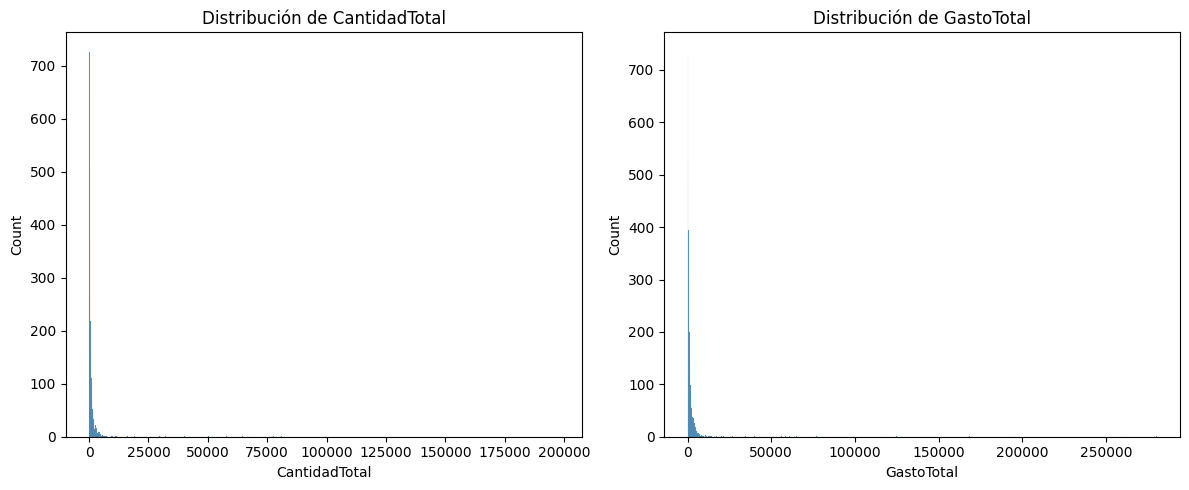

Ambas variables no siguen una distribución normal, tienen sesgo.
Usaremos MinMaxScaler para normalizar CantidadTotal y GastoTotal.

Datos transformados:
       CustomerID  TotalCompras  CantidadTotal  GastoTotal  Frecuencia  \
0          12346             1          74215    77183.60           1   
1          12347             7           2458     4310.00         182   
2          12348             4           2341     1797.24          31   
3          12349             1            631     1757.55          73   
4          12350             1            197      334.40          17   
...          ...           ...            ...         ...         ...   
4334       18280             1             45      180.60          10   
4335       18281             1             54       80.82           7   
4336       18282             2            103      178.05          12   
4337       18283            16           1397     2094.88         756   
4338       18287             3           15

In [ ]:
# Normalizar CantidadTotal y GastoTotal usando MinMaxScaler o StandardScaler.
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# graficamos las variables CantidadTotal y GastoTotal para ver su distribución
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(customer_metrics_df['CantidadTotal'], ax=axs[0])
axs[0].set_title('Distribución de CantidadTotal')

sns.histplot(customer_metrics_df['GastoTotal'], ax=axs[1])
axs[1].set_title('Distribución de GastoTotal')

plt.tight_layout()
plt.show()

print('Ambas variables no siguen una distribución normal, tienen sesgo.')
print('Usaremos MinMaxScaler para normalizar CantidadTotal y GastoTotal.')

scaler_minmax = MinMaxScaler()
customer_metrics_df[['CantidadTotal_Norm', 'GastoTotal_Norm']] = scaler_minmax.fit_transform(customer_metrics_df[['CantidadTotal', 'GastoTotal']])

print('\nDatos transformados:\n', customer_metrics_df)
#print("\nDatos transformados:\n", customer_metrics_df[['CantidadTotal_Norm', 'GastoTotal_Norm']].head())

# **3. Aplicación de Algoritmos de Clustering**

# Aplicar K-Means y determinar el número óptimo de clusters con el método del codo.

K=10 - Inercia: 0.22259687156866842


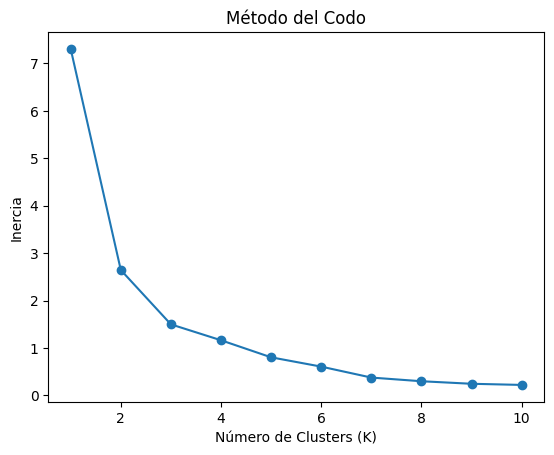

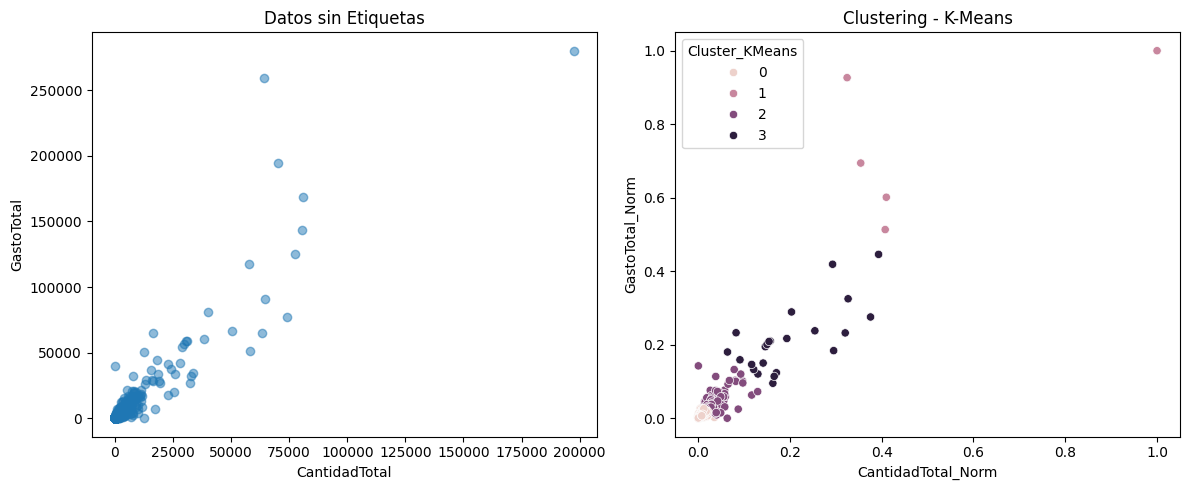

In [ ]:
# Aplicar K-Means y determinar el número óptimo de clusters con el método del codo.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Seleccioanmos las variables numéricas
X = customer_metrics_df[['CantidadTotal_Norm', 'GastoTotal_Norm']]

# Método del Codo, para determinar el mejor valor de K
inercia = []
valores_k = range(1, 11)
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

print(f'K={k} - Inercia: {kmeans.inertia_}')

plt.plot(valores_k, inercia, marker='o', linestyle='-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

# Aplicamos K-Means con K=4, valor ótimo
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
customer_metrics_df['Cluster_KMeans'] = kmeans.fit_predict(X)
#labels_km = customer_metrics_df['Cluster_KMeans']

# Visualizar ambos gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1 - Datos sin etiquetas
axes[0].scatter(customer_metrics_df['CantidadTotal'], customer_metrics_df['GastoTotal'], alpha=0.5)
axes[0].set_xlabel('CantidadTotal')
axes[0].set_ylabel('GastoTotal')
axes[0].set_title('Datos sin Etiquetas')

# Gráfico 2 - Clustering
sns.scatterplot(data=customer_metrics_df, x='CantidadTotal_Norm', y='GastoTotal_Norm',
                hue='Cluster_KMeans', ax=axes[1])
axes[1].set_xlabel('CantidadTotal_Norm')
axes[1].set_ylabel('GastoTotal_Norm')
axes[1].set_title('Clustering - K-Means')

plt.tight_layout()
plt.show()

#Aplicar DBScan ajustando eps y min_samples para detectar clientes "outliers".

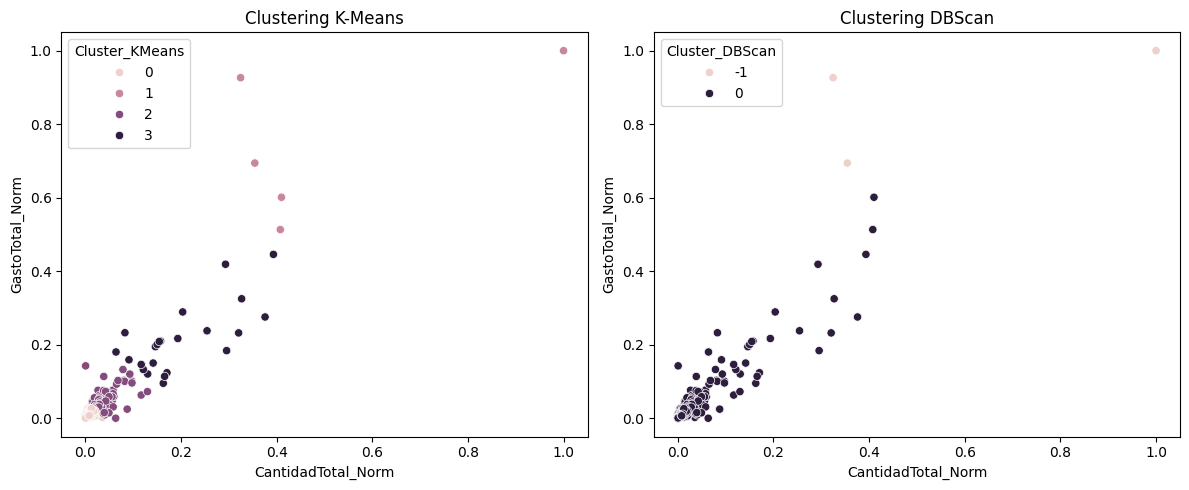

In [ ]:
# Aplicar DBScan ajustando eps y min_samples para detectar clientes "outliers".
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Seleccionamos características
X = customer_metrics_df[['CantidadTotal_Norm', 'GastoTotal_Norm']].values

# Aplica DBScan
#dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan = DBSCAN(eps=0.15, min_samples=4)
customer_metrics_df['Cluster_DBScan'] = dbscan.fit_predict(X)

# Visualizamos ambos gráficos: K-Means y DBScan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1 - K-Means
sns.scatterplot(data=customer_metrics_df, x='CantidadTotal_Norm', y='GastoTotal_Norm',
                hue='Cluster_KMeans', ax=axes[0])
axes[0].set_xlabel('CantidadTotal_Norm')
axes[0].set_ylabel('GastoTotal_Norm')
axes[0].set_title('Clustering K-Means')

# Gráfico 1 - DBScan
sns.scatterplot(data=customer_metrics_df, x='CantidadTotal_Norm', y='GastoTotal_Norm',
                hue='Cluster_DBScan', ax=axes[1])
axes[1].set_xlabel('CantidadTotal_Norm')
axes[1].set_ylabel('GastoTotal_Norm')
axes[1].set_title('Clustering DBScan')

plt.tight_layout()
plt.show()

# **4. Evaluación del Clustering**

# Comparar resultados con Silhouette Score y Davies-Bouldin Index.

In [ ]:
# Comparar resultados con Silhouette Score y Davies-Bouldin Index
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# Escalar los datos
scaler_standard = StandardScaler()
X_scaled = scaler_standard.fit_transform(X)

labels_km = customer_metrics_df['Cluster_KMeans']
labels_db = customer_metrics_df['Cluster_DBScan']

# Aplicamos K-MEANS
silhouette_kmeans = silhouette_score(X_scaled, labels_km)
dbi_kmeans = davies_bouldin_score(X_scaled, labels_km)

print("K-MEANS")
print(f"Silhouette - K-Means: {silhouette_kmeans:.2f}")
print(f"Davies-Bouldin - K-Means: {dbi_kmeans:.2f}")

# Aplicamos DBSCAN

# Excluir ruido (-1)
mask = labels_db != -1

# Contamos la cantidad de clusters válidos
n_clusters = len(set(labels_db[mask]))

print("\nDBSCAN")

if n_clusters > 1:

    silhouette_dbscan = silhouette_score(
        X_scaled[mask],
        labels_db[mask]
    )

    dbi_dbscan = davies_bouldin_score(
        X_scaled[mask],
        labels_db[mask]
    )

    print(f"Silhouette - DBScan: {silhouette_dbscan:.2f}")
    print(f"Davies-Bouldin - DBScan: {dbi_dbscan:.2f}")

else:
    print("No se pueden calcular las métricas.")
    print("DBSCAN no encontró al menos dos clusters válidos.")
    print("Considere ajustar 'eps' o 'min_samples'.")

K-MEANS
Silhouette - K-Means: 0.84
Davies-Bouldin - K-Means: 0.63

DBSCAN
No se pueden calcular las métricas.
DBSCAN no encontró al menos dos clusters válidos.
Considere ajustar 'eps' o 'min_samples'.


# Justificar cuál método produce mejor segmentación de clientes y por qué.

K-Means produce mejor segmentación de los datos. Se formaron 4 grupos bien definidos y separados. El valor de Silhouette=0.84 indica una buena cohesión y separación entre grupos. El valor Davies-Bouldin=0.63 confirma una segmentación de buena calidad.
DBSCAN no pudo encontrar al menos dos clusters válidos, por lo que no fue posible calcular las métricas. Esto se debe a que DBSCAN es más sensible a la densidad de los datos y a los parámetros utilizados (eps y min_samples).

# **5. Interacción con una Herramienta de IA (LLM)**

# Consulta sugerida: "Tengo un dataset de transacciones de clientes de e-commerce. ¿Qué técnicas de clustering me recomendarías para segmentarlos?"

Para segmentar clientes de un e-commerce, recomendaría distintas técnicas de clustering según el tipo de datos y el objetivo del análisis:

**K-Means**: ideal para segmentar clientes según métricas como gasto total, frecuencia de compra o cantidad de productos. Es rápido y funciona bien cuando los grupos son compactos y definidos.

**DBSCAN**: útil para detectar clientes atípicos o comportamientos inusuales, ya que puede identificar outliers y clusters de diferentes formas.

**Clustering Jerárquico**: recomendable cuando se quiere explorar relaciones entre segmentos y visualizar agrupamientos mediante dendrogramas.

**Gaussian Mixture Models (GMM)**: apropiado si los clientes pueden pertenecer parcialmente a varios segmentos o los grupos tienen formas más complejas.

**RFM + Clustering**: una estrategia muy usada en e-commerce es combinar variables de Recencia, Frecuencia y Valor Monetario (RFM) y luego aplicar K-Means para identificar clientes VIP, frecuentes o inactivos.

La elección depende de:

* la cantidad de clientes,
* la presencia de outliers,
* la forma de los grupos,
* y si se conocen o no patrones previos en los datos.

# Comparar la respuesta del LLM con lo aprendido en clase y reflexionar sobre su utilidad.

El texto coincide con los conceptos vistos en clase sobre clustering aplicado a e-commerce. K-Means es eficiente para grupos compactos y bien definidos, mientras que DBSCAN destaca por detectar clusters irregulares y outliers. La elección del algoritmo depende de la forma de los datos, la presencia de ruido y la cantidad de clusters esperados. La validación con métricas como Silhouette y Davies-Bouldin es fundamental para la aplicación del modelo aprendizaje no supervisado. También se resalta la importancia de escalar los datos para evitar distorsiones entre variables de distinta magnitud.

# **Reflexión Final de la Clase**

# ¿Cuál algoritmo de clustering fue más efectivo en este ejercicio?

Para éste algoritmo fue mejor utilizar K-Means, ya que permitió obtener 4 cluster definidos. Mientras que DBScan, identificó sólo un cluster y permitió identificar valores outliers.

# ¿Cómo podríamos mejorar la precisión de la segmentación?

Para mejorar la precisión de la segmentación de clientes es importante optimizar los parámetros de los algoritmos y elegir el método de clustering más adecuado según los datos. También es fundamental realizar un buen preprocesamiento: limpiar datos, eliminar inconsistencias y escalar variables con técnicas como StandardScaler o MinMaxScaler. Métodos como el Coeficiente de Silhouette y el Índice de Davies-Bouldin ayudan a evaluar y comparar la calidad de los clusters. Además, técnicas como PCA pueden reducir ruido y mejorar la separación entre grupos.

# ¿Qué limitaciones tiene el clustering en la minería de datos?

El clustering tiene limitaciones, como la sensibilidad a outliers, la dependencia de parámetros y la dificultad para trabajar con clusters superpuestos o de formas complejas. Por eso, se recomienda probar distintos algoritmos y ajustar hiperparámetros de manera iterativa.